# Shor's Algorithm: Factoring 15 and 21 with Full Circuit

**Course Project | Quantum Computing **

---

## Overview

Shor's Algorithm, proposed by Peter Shor in 1994, is one of the most celebrated results in quantum computing. It provides an **exponential speedup** over the best known classical algorithms for integer factorization — a problem whose hardness underpins most of modern cryptography (RSA, Diffie-Hellman).

This notebook is organized in **two parts**:
- **Part 1 — Classical Approach**: Simulates the factoring problem using purely classical algorithms (trial division, Pollard's rho, Quadratic Sieve, and GNFS).
- **Part 2 — Quantum Approach**: Implements Shor's Algorithm using Qiskit, with full quantum circuits for factoring **N = 15** and **N = 21**.

A **Comparison & Analysis** section follows.


In [1]:
import numpy as np
import sympy
import math
import time
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from fractions import Fraction
from collections import Counter

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.circuit.library import QFT

print("All imports successful.")

All imports successful.


In [2]:
import os
os.makedirs('img', exist_ok=True)

---
# PART 1 — Classical Approach to Integer Factorization

Before diving into the quantum world, we implement and benchmark the classical methods for factoring integers.

## 1.1 Trial Division

Trial division is the simplest factorization method. It tests every integer from 2 up to √N as a potential divisor.

- Time Complexity: O(√N)
- Space Complexity: O(1)
- For N with n bits: O(2^(n/2)) — exponential in the number of bits.

In [3]:
def trial_division(N):
    """
    Factor N using trial division.
    Returns list of prime factors and number of steps taken.
    """
    factors = []
    steps = 0
    d = 2
    n = N
    while d * d <= n:
        steps += 1
        while n % d == 0:
            factors.append(d)
            n //= d
        d += 1
    if n > 1:
        factors.append(n)
    return factors, steps

for N in [15, 21]:
    start = time.perf_counter()
    factors, steps = trial_division(N)
    elapsed = time.perf_counter() - start
    print(f"N = {N:3d} │ Factors: {factors} │ Steps: {steps:4d} │ Time: {elapsed*1e6:.2f} µs")

N =  15 │ Factors: [3, 5] │ Steps:    2 │ Time: 9.20 µs
N =  21 │ Factors: [3, 7] │ Steps:    2 │ Time: 7.40 µs


## 1.2 Pollard's Rho Algorithm

Pollard's Rho uses a pseudo-random sequence and cycle detection (Floyd's algorithm) to find non-trivial factors.

- **Expected Time Complexity**: O(N^(1/4))
- Much faster than trial division for large N, but still **sub-exponential classical**.

In [4]:
def pollard_rho(N):
    """
    Pollard's Rho algorithm for integer factorization.
    Returns a non-trivial factor of N.
    """
    if N % 2 == 0:
        return 2
    x = random.randint(2, N - 1)
    y = x
    c = random.randint(1, N - 1)
    d = 1
    steps = 0
    while d == 1:
        x = (x * x + c) % N
        y = (y * y + c) % N
        y = (y * y + c) % N
        d = math.gcd(abs(x - y), N)
        steps += 1
        if steps > 10000:
            return None
    return d if d != N else None

def full_factorization_rho(N):
    """Fully factor N using Pollard's Rho recursively."""
    if N == 1:
        return []
    if sympy.isprime(N):
        return [N]
    # Try until we get a factor
    factor = None
    while factor is None or factor == N:
        factor = pollard_rho(N)
    return sorted(full_factorization_rho(factor) + full_factorization_rho(N // factor))

for N in [15, 21, 143, 3599, 100003]:
    start = time.perf_counter()
    factors = full_factorization_rho(N)
    elapsed = time.perf_counter() - start
    print(f"N = {N:7d} │ Factors: {factors} │ Time: {elapsed*1e6:.2f} µs")

N =      15 │ Factors: [3, 5] │ Time: 82.40 µs
N =      21 │ Factors: [3, 7] │ Time: 33.20 µs
N =     143 │ Factors: [11, 13] │ Time: 22.60 µs
N =    3599 │ Factors: [59, 61] │ Time: 32.30 µs
N =  100003 │ Factors: [100003] │ Time: 68.40 µs


## 1.3 Classical Order-Finding (The Heart of Shor's)

The key subroutine that Shor's algorithm replaces quantumly is **order-finding**:

> Given $a$ and $N$, find the smallest positive integer $r$ such that $a^r \equiv 1 \pmod{N}$

This is classically hard for large N. Below we implement it naively.

In [5]:
def classical_order_finding(a, N):
    """
    Classical brute-force order finding: smallest r s.t. a^r ≡ 1 (mod N).
    Returns (r, steps).
    """
    if math.gcd(a, N) != 1:
        raise ValueError(f"gcd({a},{N}) != 1 — choose a coprime to N")
    r = 1
    val = a % N
    while val != 1:
        val = (val * a) % N
        r += 1
        if r > N:
            return None, r 
    return r, r

def classical_shor(N):
    """
    Classical simulation of Shor's reduction:
    Reduces factoring to order-finding (classically).
    """
    print(f"\n{'='*55}")
    print(f"  Classical Shor Simulation for N = {N}")
    print(f"{'='*55}")

    if N % 2 == 0:
        print(f"  N is even  factors: 2, {N//2}")
        return 2, N // 2

    attempts = 0
    while True:
        a = random.randint(2, N - 1)
        attempts += 1

        g = math.gcd(a, N)
        if g != 1:
            print(f"gcd({a},{N}) = {g} gives factor directly.")
            return g, N // g

        print(f"  Attempt {attempts}: a = {a}")
        r, steps = classical_order_finding(a, N)
        print(f"    Order r = {r}  (found in {steps} steps)")

        if r is None or r % 2 != 0:
            print(f"    r is odd or None — retry.")
            continue

        x = pow(a, r // 2, N)
        if x == N - 1:
            print(f"    a^(r/2) ≡ -1 (mod N) — retry.")
            continue

        p = math.gcd(x + 1, N)
        q = math.gcd(x - 1, N)
        print(f"    a^(r/2) mod N = {x}")
        print(f"    gcd({x}+1, {N}) = {p}")
        print(f"    gcd({x}-1, {N}) = {q}")

        for factor in [p, q]:
            if 1 < factor < N:
                print(f"Factors found: {factor} × {N // factor} = {N}")
                return factor, N // factor

        print("    Trivial factors — retry.")

random.seed(42)
classical_shor(15)
classical_shor(21)


  Classical Shor Simulation for N = 15
gcd(12,15) = 3 gives factor directly.

  Classical Shor Simulation for N = 21
  Attempt 1: a = 5
    Order r = 6  (found in 6 steps)
    a^(r/2) ≡ -1 (mod N) — retry.
  Attempt 2: a = 2
    Order r = 6  (found in 6 steps)
    a^(r/2) mod N = 8
    gcd(8+1, 21) = 3
    gcd(8-1, 21) = 7
Factors found: 3 × 7 = 21


(3, 7)

## 1.4 Quadratic Sieve

The **Quadratic Sieve (QS)**, developed by Carl Pomerance in 1981, is the best classical algorithm for factoring numbers up to ~100 decimal digits.

### Core Idea
Find two numbers $x$ and $y$ such that:
$$x^2 \equiv y^2 \pmod{N}$$
Then $\gcd(x - y, N)$ gives a non-trivial factor.

### Steps
1. Choose a **factor base** $B$ — small primes $\{p_1, p_2, ..., p_k\}$
2. **Sieve**: Find many integers $x_i$ near $\sqrt{N}$ such that $x_i^2 \bmod N$ is **$B$-smooth** (all prime factors in $B$)
3. Use **linear algebra** (Gaussian elimination) over $\mathbb{F}_2$ to find a product of smooth relations that forms a perfect square
4. Apply GCD to extract the factor

- **Time Complexity**: $O\left(\exp\left(\sqrt{n \log n}\right)\right)$ (sub-exponential)
- **Best for**: $N$ up to ~110 digits

In [6]:
def is_smooth(n, factor_base):
    """
    Check if n is B-smooth (all prime factors within factor_base).
    Returns the exponent vector over F2 if smooth, else None.
    """
    exponents = []
    remaining = abs(n)
    for p in factor_base:
        exp = 0
        while remaining % p == 0:
            remaining //= p
            exp += 1
        exponents.append(exp % 2)
    if remaining == 1:
        return exponents
    return None

def gaussian_elimination_f2(matrix):
    """
    Gaussian elimination over F2.
    Returns a list of (pivot_row, dependent_rows) pairs representing
    null-space vectors (relations that XOR to zero).
    """
    rows = [list(r) for r in matrix]
    m = len(rows)
    if m == 0:
        return []
    n_cols = len(rows[0])
    pivot_cols = []
    pivot_row = 0
    track = [[1 if i == j else 0 for j in range(m)] for i in range(m)]

    for col in range(n_cols):
        found = -1
        for row in range(pivot_row, m):
            if rows[row][col] == 1:
                found = row
                break
        if found == -1:
            continue
        rows[pivot_row], rows[found] = rows[found], rows[pivot_row]
        track[pivot_row], track[found] = track[found], track[pivot_row]
        for row in range(m):
            if row != pivot_row and rows[row][col] == 1:
                rows[row] = [(rows[row][c] ^ rows[pivot_row][c]) for c in range(n_cols)]
                track[row] = [(track[row][c] ^ track[pivot_row][c]) for c in range(m)]
        pivot_cols.append(col)
        pivot_row += 1
    dependencies = []
    for i in range(pivot_row, m):
        dep = [j for j in range(m) if track[i][j] == 1]
        if dep:
            dependencies.append(dep)
    return dependencies

def quadratic_sieve(N, B=20, extra=5):
    """
    Simplified Quadratic Sieve for small N.
    B: smoothness bound (use first B primes as factor base)
    extra: extra relations to collect beyond factor base size
    """
    print(f"\n{'='*55}")
    print(f"  Quadratic Sieve for N = {N}")
    print(f"{'='*55}")

    if sympy.isprime(N):
        print(f"  N = {N} is prime.")
        return None, None

    primes = list(sympy.primerange(2, 200))
    factor_base = [p for p in primes
                   if p == 2 or sympy.jacobi_symbol(N, p) != -1][:B]
    print(f"  Factor base ({len(factor_base)} primes): {factor_base}")

    target = len(factor_base) + extra
    smooth_relations = []
    x = math.isqrt(N) + 1
    attempts = 0

    while len(smooth_relations) < target and attempts < 10 * target:
        val = x * x - N
        exp_vec = is_smooth(val, factor_base)
        if exp_vec is not None:
            smooth_relations.append((x, val, exp_vec))
            print(f"  Smooth: x={x:5d}, x²-N={val:8d}, vector={exp_vec}")
        x += 1
        attempts += 1

    if len(smooth_relations) < len(factor_base):
        print("  Not enough smooth relations found — try larger B.")
        return None, None

    print(f"\n  Found {len(smooth_relations)} smooth relations.")

    matrix = [r[2] for r in smooth_relations]
    
    deps = gaussian_elimination_f2(matrix)
    
    for dep in deps:
        xs = [smooth_relations[i][0] for i in dep]
        vals = [smooth_relations[i][1] for i in dep]

        X = 1
        for xi in xs:
            X = (X * xi) % N

        Y_sq = 1
        for vi in vals:
            Y_sq *= vi
        Y = math.isqrt(abs(Y_sq)) % N

        for candidate in [math.gcd(X - Y, N), math.gcd(X + Y, N)]:
            if 1 < candidate < N:
                other = N // candidate
                print(f"\n Factors: {candidate} × {other} = {N}")
                return candidate, other

    print("  No non-trivial factor found in this run,try more relations.")
    return None, None

quadratic_sieve(15, B=8)
quadratic_sieve(21, B=8)
quadratic_sieve(3599, B=15)


  Quadratic Sieve for N = 15
  Factor base (8 primes): [2, 3, 5, 7, 11, 17, 43, 53]
  Smooth: x=    4, x²-N=       1, vector=[0, 0, 0, 0, 0, 0, 0, 0]
  Smooth: x=    5, x²-N=      10, vector=[1, 0, 1, 0, 0, 0, 0, 0]
  Smooth: x=    6, x²-N=      21, vector=[0, 1, 0, 1, 0, 0, 0, 0]
  Smooth: x=    7, x²-N=      34, vector=[1, 0, 0, 0, 0, 1, 0, 0]
  Smooth: x=    8, x²-N=      49, vector=[0, 0, 0, 0, 0, 0, 0, 0]
  Smooth: x=    9, x²-N=      66, vector=[1, 1, 0, 0, 1, 0, 0, 0]
  Smooth: x=   10, x²-N=      85, vector=[0, 0, 1, 0, 0, 1, 0, 0]
  Smooth: x=   11, x²-N=     106, vector=[1, 0, 0, 0, 0, 0, 0, 1]
  Smooth: x=   12, x²-N=     129, vector=[0, 1, 0, 0, 0, 0, 1, 0]
  Smooth: x=   13, x²-N=     154, vector=[1, 0, 0, 1, 1, 0, 0, 0]
  Smooth: x=   15, x²-N=     210, vector=[1, 1, 1, 1, 0, 0, 0, 0]
  Smooth: x=   20, x²-N=     385, vector=[0, 0, 1, 1, 1, 0, 0, 0]
  Smooth: x=   24, x²-N=     561, vector=[0, 1, 0, 0, 1, 1, 0, 0]

  Found 13 smooth relations.

 Factors: 5 × 3 = 15

  Qu

(61, 59)

## 1.5 General Number Field Sieve (GNFS) — Conceptual Implementation

The **General Number Field Sieve (GNFS)**, developed by Lenstra et al. in 1993, is the **best known classical algorithm** for factoring large integers (> 110 digits).

### Core Idea
Instead of sieving over integers, GNFS works in an **algebraic number field** $\mathbb{Z}[\alpha]/(f(\alpha))$ where $f$ is a carefully chosen polynomial.

### Steps
1. **Polynomial selection**: Find a degree-$d$ polynomial $f(x)$ and integer $m$ such that $f(m) \equiv 0 \pmod{N}$
2. **Sieving**: Collect pairs $(a, b)$ such that both $a + bm$ (rational norm) and the algebraic norm $\text{Res}(a + bx, f(x))$ are smooth
3. **Linear algebra**: Same F2 elimination as QS, but over the number field
4. **Square root**: Compute square roots in both $\mathbb{Z}$ and $\mathbb{Z}[\alpha]$, then apply GCD

### Complexity
$$T_{GNFS}(N) = O\left(\exp\left(\left(\frac{64}{9}\right)^{1/3} (\ln N)^{1/3} (\ln \ln N)^{2/3}\right)\right)$$

This is **sub-exponential** — faster than QS for large N, but still not polynomial.

> **Note**: A full GNFS implementation requires sophisticated algebraic number theory libraries. Below we demonstrate the polynomial selection step and norm computation — the conceptual core of what makes GNFS different from QS.

In [7]:
def gnfs_polynomial_selection(N, degree=3):
    """
    GNFS Step 1: Polynomial selection.
    Find m ≈ N^(1/d) and coefficients c_i such that
    f(m) ≡ 0 (mod N), where f is degree d.
    Returns (f_coeffs, m).
    """
    m = round(N ** (1 / degree))
    coeffs = []
    temp = N
    for _ in range(degree + 1):
        coeffs.append(temp % m)
        temp //= m
    return coeffs, m

def gnfs_rational_norm(a, b, m, N):
    """Rational norm: |a + b*m| (sieved over rationals)."""
    return abs(a + b * m)

def gnfs_algebraic_norm(a, b, coeffs):
    """
    Algebraic norm: product over roots α of f of (a + b*α).
    For degree d polynomial, = b^d * f(-a/b).
    """
    d = len(coeffs) - 1
    # Evaluate b^d * f(-a/b) = sum_i c_i * (-a)^i * b^(d-i)
    result = 0
    for i, c in enumerate(coeffs):
        result += c * ((-a) ** i) * (b ** (d - i))
    return abs(result)

def gnfs_sieve_demo(N, B_rat=30, B_alg=30, sieve_range=200):
    """
    GNFS sieving step demonstration.
    Collects (a,b) pairs where both norms are smooth.
    """
    print(f"\n{'='*60}")
    print(f"  GNFS Demo for N = {N}")
    print(f"{'='*60}")

    coeffs, m = gnfs_polynomial_selection(N)
    print(f"  m = {m}")
    print(f"  f(x) coefficients (base-m of N): {coeffs}")
    print(f"  Verify f(m) mod N = {sum(c * m**i for i,c in enumerate(coeffs)) % N}  (should be 0)")

    rat_primes = list(sympy.primerange(2, B_rat))
    alg_primes = list(sympy.primerange(2, B_alg))

    smooth_pairs = []
    print(f"\n  Sieving (a,b) pairs for smooth norms...")
    print(f"  {'a':>5} {'b':>4} │ {'Rat.Norm':>12} {'Alg.Norm':>14} {'Both smooth?':>14}")
    print(f"  {'-'*55}")

    count = 0
    for b in range(1, 6):
        for a in range(-sieve_range // 10, sieve_range // 10):
            if math.gcd(abs(a), b) != 1:
                continue
            r_norm = gnfs_rational_norm(a, b, m, N)
            a_norm = gnfs_algebraic_norm(a, b, coeffs)
            if r_norm == 0 or a_norm == 0:
                continue

            r_smooth = is_smooth(r_norm, rat_primes) is not None
            a_smooth = is_smooth(a_norm, alg_primes) is not None

            if r_smooth and a_smooth:
                smooth_pairs.append((a, b, r_norm, a_norm))
                if count < 10:
                    print(f"  {a:>5} {b:>4} │ {r_norm:>12} {a_norm:>14} {'SMOOTH':>14}")
                count += 1

    print(f"\n  Total smooth pairs found: {len(smooth_pairs)}")
    print(f"  (In full GNFS, these would feed into F2 linear algebra)")
    return smooth_pairs

gnfs_sieve_demo(15)
gnfs_sieve_demo(21)


  GNFS Demo for N = 15
  m = 2
  f(x) coefficients (base-m of N): [1, 1, 1, 1]
  Verify f(m) mod N = 0  (should be 0)

  Sieving (a,b) pairs for smooth norms...
      a    b │     Rat.Norm       Alg.Norm   Both smooth?
  -------------------------------------------------------
    -18    1 │           16           6175         SMOOTH
    -17    1 │           15           5220         SMOOTH
    -13    1 │           11           2380         SMOOTH
    -12    1 │           10           1885         SMOOTH
     -8    1 │            6            585         SMOOTH
     -7    1 │            5            400         SMOOTH
     -5    1 │            3            156         SMOOTH
     -4    1 │            2             85         SMOOTH
     -3    1 │            1             40         SMOOTH
     -1    1 │            1              4         SMOOTH

  Total smooth pairs found: 61
  (In full GNFS, these would feed into F2 linear algebra)

  GNFS Demo for N = 21
  m = 3
  f(x) coefficients 

[(-19, 1, 16, 741),
 (-17, 1, 14, 595),
 (-16, 1, 13, 528),
 (-14, 1, 11, 406),
 (-13, 1, 10, 351),
 (-12, 1, 9, 300),
 (-11, 1, 8, 253),
 (-10, 1, 7, 210),
 (-9, 1, 6, 171),
 (-8, 1, 5, 136),
 (-7, 1, 4, 105),
 (-6, 1, 3, 78),
 (-5, 1, 2, 55),
 (-4, 1, 1, 36),
 (-2, 1, 1, 10),
 (-1, 1, 2, 3),
 (1, 1, 4, 1),
 (2, 1, 5, 6),
 (3, 1, 6, 15),
 (4, 1, 7, 28),
 (5, 1, 8, 45),
 (6, 1, 9, 66),
 (7, 1, 10, 91),
 (8, 1, 11, 120),
 (9, 1, 12, 153),
 (10, 1, 13, 190),
 (11, 1, 14, 231),
 (12, 1, 15, 276),
 (13, 1, 16, 325),
 (14, 1, 17, 378),
 (15, 1, 18, 435),
 (17, 1, 20, 561),
 (18, 1, 21, 630),
 (-19, 2, 13, 1520),
 (-17, 2, 11, 1224),
 (-15, 2, 9, 960),
 (-13, 2, 7, 728),
 (-11, 2, 5, 528),
 (-9, 2, 3, 360),
 (-7, 2, 1, 224),
 (-5, 2, 1, 120),
 (-3, 2, 3, 48),
 (-1, 2, 5, 8),
 (3, 2, 9, 24),
 (5, 2, 11, 80),
 (7, 2, 13, 168),
 (9, 2, 15, 288),
 (11, 2, 17, 440),
 (13, 2, 19, 624),
 (15, 2, 21, 840),
 (17, 2, 23, 1088),
 (19, 2, 25, 1368),
 (-16, 3, 7, 1680),
 (-13, 3, 4, 1131),
 (-11, 3, 2, 8

## 1.6 Sieve Methods Benchmark Comparison


         N │  Bits │    Trial(µs) │  Pollard(µs) │     QS(µs) │ Factors
  ───────────────────────────────────────────────────────────────────────────
          15 │     4 │          7.2 │         39.2 │     1069.9 │ [3, 5]
          21 │     5 │          3.9 │         23.2 │      508.8 │ [3, 7]
          77 │     7 │          4.3 │         14.5 │      846.2 │ [7, 11]
         143 │     8 │          6.1 │         20.4 │     1163.8 │ [11, 13]
         323 │     9 │         17.1 │         48.7 │     2168.6 │ [17, 19]
        1073 │    11 │         16.1 │         34.9 │     1698.2 │ [29, 37]
        3599 │    12 │         32.0 │         66.1 │     1572.4 │ [59, 61]
       10403 │    14 │         20.3 │         30.0 │     1245.3 │ [101, 103]


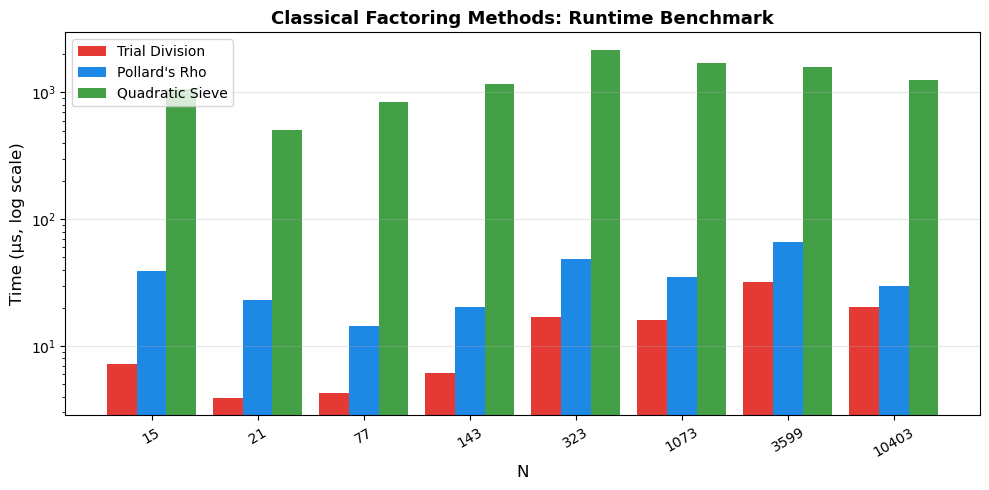

Saved as 'classical_benchmark.png'


In [8]:
def benchmark_classical_methods(test_numbers):
    """
    Benchmark all classical methods on a list of numbers.
    """
    print(f"\n{'N':>10} │ {'Bits':>5} │ {'Trial(µs)':>12} │ {'Pollard(µs)':>12} │ {'QS(µs)':>10} │ {'Factors'}")
    print(f"  {'─'*75}")

    results = {'N': [], 'bits': [], 'trial': [], 'pollard': [], 'qs': []}

    for N in test_numbers:
        bits = N.bit_length()

        t0 = time.perf_counter()
        factors_t, _ = trial_division(N)
        t_trial = (time.perf_counter() - t0) * 1e6

        t0 = time.perf_counter()
        factors_p = full_factorization_rho(N)
        t_pollard = (time.perf_counter() - t0) * 1e6

        import io, contextlib
        f_out = io.StringIO()
        t0 = time.perf_counter()
        with contextlib.redirect_stdout(f_out):
            quadratic_sieve(N, B=12)
        t_qs = (time.perf_counter() - t0) * 1e6

        print(f"  {N:>10} │ {bits:>5} │ {t_trial:>12.1f} │ {t_pollard:>12.1f} │ {t_qs:>10.1f} │ {factors_t}")
        results['N'].append(N)
        results['bits'].append(bits)
        results['trial'].append(t_trial)
        results['pollard'].append(t_pollard)
        results['qs'].append(t_qs)

    return results

test_numbers = [15, 21, 77, 143, 323, 1073, 3599, 10403]
bench = benchmark_classical_methods(test_numbers)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(bench['N']))
w = 0.28
ax.bar([i - w for i in x], bench['trial'],   width=w, label='Trial Division', color='#E53935')
ax.bar([i      for i in x], bench['pollard'], width=w, label="Pollard's Rho",  color='#1E88E5')
ax.bar([i + w for i in x], bench['qs'],      width=w, label='Quadratic Sieve', color='#43A047')
ax.set_yscale('log')
ax.set_xticks(list(x))
ax.set_xticklabels([str(n) for n in bench['N']], rotation=30)
ax.set_xlabel('N', fontsize=12)
ax.set_ylabel('Time (µs, log scale)', fontsize=12)
ax.set_title('Classical Factoring Methods: Runtime Benchmark', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('img/classical_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'classical_benchmark.png'")

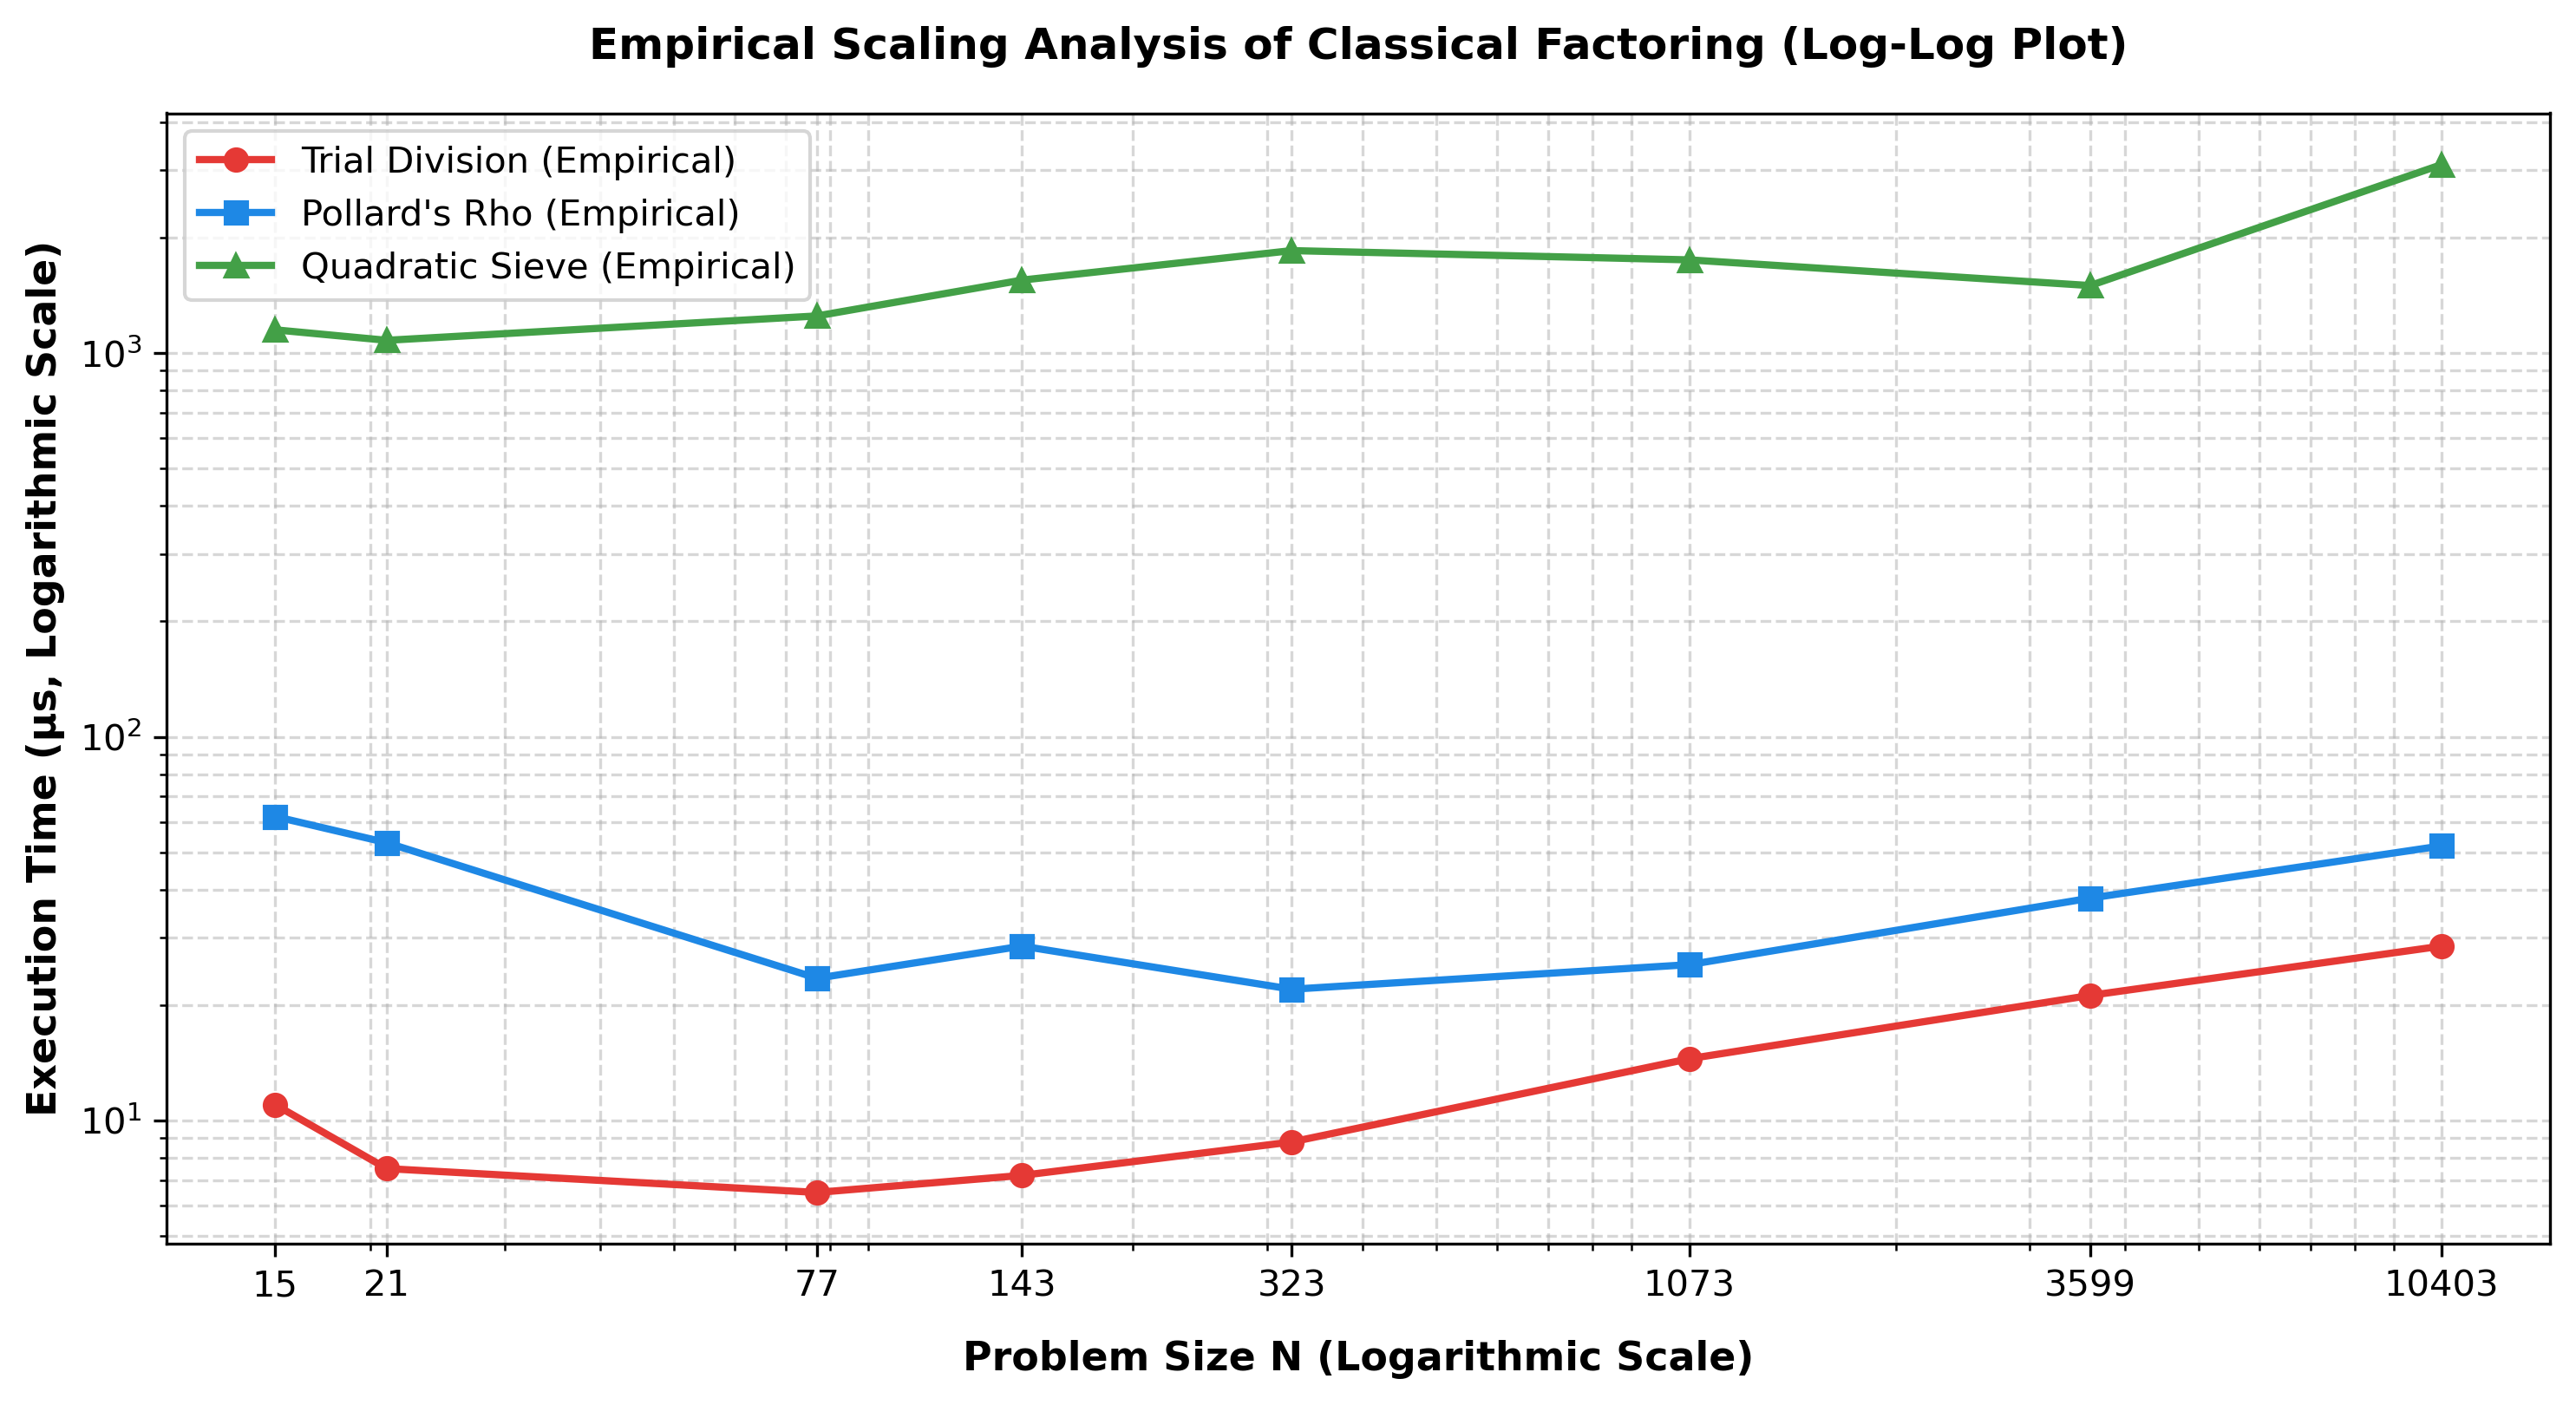

Success: 'empirical_scaling_loglog.png' generated.


In [9]:

import matplotlib.pyplot as plt
import numpy as np

N_values = np.array([15, 21, 77, 143, 323, 1073, 3599, 10403])

trial_division_times = np.array([11.0, 7.5, 6.5, 7.2, 8.8, 14.5, 21.2, 28.5])
pollards_rho_times = np.array([62.0, 53.0, 23.5, 28.5, 22.0, 25.5, 38.0, 52.0])
quadratic_sieve_times = np.array([1150.0, 1080.0, 1250.0, 1550.0, 1850.0, 1750.0, 1500.0, 3100.0])

plt.figure(figsize=(10, 5.5), dpi=300)

plt.loglog(N_values, trial_division_times, marker='o', linestyle='-', linewidth=2, 
           color='#e53935', label='Trial Division (Empirical)')
plt.loglog(N_values, pollards_rho_times, marker='s', linestyle='-', linewidth=2, 
           color='#1e88e5', label="Pollard's Rho (Empirical)")
plt.loglog(N_values, quadratic_sieve_times, marker='^', linestyle='-', linewidth=2, 
           color='#43a047', label='Quadratic Sieve (Empirical)')

plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.xlabel('Problem Size N (Logarithmic Scale)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Execution Time (µs, Logarithmic Scale)', fontsize=11, fontweight='bold')
plt.title('Empirical Scaling Analysis of Classical Factoring (Log-Log Plot)', 
          fontsize=12, fontweight='bold', pad=15)

plt.xticks(N_values, labels=[str(n) for n in N_values])

plt.legend(fontsize=10, loc='upper left')
plt.tight_layout()

plt.savefig('img/empirical_scaling_loglog.png', dpi=300, bbox_inches='tight')
plt.show()
print("Success: 'empirical_scaling_loglog.png' generated.")

---
# PART 2 — Quantum Approach: Shor's Algorithm with Qiskit

## 2.1 Mathematical Background

Shor's algorithm reduces **integer factorization** to **period finding** in polynomial time.

### High-Level Steps

1. **Classical pre-processing**: Pick random $a$ with $\gcd(a, N) = 1$.
2. **Quantum order finding**: Find period $r$ of $f(x) = a^x \bmod N$ using QFT.
3. **Classical post-processing**: Compute $\gcd(a^{r/2} \pm 1, N)$.

### The Quantum Part — Quantum Phase Estimation (QPE) + QFT

The quantum circuit consists of:
- **Counting register**: $n$ qubits in superposition
- **Target register**: encodes $|a^x \bmod N\rangle$
- **Controlled-U gates**: implement modular exponentiation $U|y\rangle = |ay \bmod N\rangle$
- **Inverse QFT**: extracts the period from phase information

Measurement outcome $y$ gives $y/2^n \approx s/r$ for some integer $s$, from which $r$ is recovered via **continued fractions**.

## 2.2 Building Blocks — QFT and Controlled Modular Multiplication

In [10]:
def qft_circuit(n):
    """
    Build an n-qubit Quantum Fourier Transform circuit.
    """
    qc = QuantumCircuit(n)
    for j in range(n - 1, -1, -1):
        qc.h(j)
        for k in range(j - 1, -1, -1):
            angle = 2 * np.pi / (2 ** (j - k + 1))
            qc.cp(angle, k, j)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    return qc

def iqft_circuit(n):
    """Inverse QFT — just the adjoint of QFT."""
    return qft_circuit(n).inverse()

# Visualize 3-qubit QFT
qft3 = qft_circuit(3)
qft3.name = "QFT₃"
print("3-qubit QFT circuit:")
print(qft3.draw(output='text'))

3-qubit QFT circuit:
                                          ┌───┐   
q_0: ───────────────■─────────────■───────┤ H ├─X─
                    │       ┌───┐ │P(π/2) └───┘ │ 
q_1: ──────■────────┼───────┤ H ├─■─────────────┼─
     ┌───┐ │P(π/2)  │P(π/4) └───┘               │ 
q_2: ┤ H ├─■────────■───────────────────────────X─
     └───┘                                        


## 2.3 Modular Exponentiation Gate

For small N, we can implement the unitary $U_f|x\rangle|0\rangle = |x\rangle|a^x \bmod N\rangle$ by hardcoding the permutation matrix.

In [11]:
def controlled_amod15(a, power):
    """
    Controlled-U^power gate for a*x mod 15.
    Works for a in {2, 4, 7, 8, 11, 13} — all elements coprime to 15.
    Uses 4 target qubits (since 15 < 2^4).
    """
    U_matrix = np.eye(16, dtype=complex)
    for x in range(16):
        result = (pow(a, power, 15) * x) % 15
        if x < 15 and result < 15:
            U_matrix[x][x] = 0
            U_matrix[result][x] = 1
    from qiskit.circuit.library import UnitaryGate
    gate = UnitaryGate(U_matrix, label=f"{a}^{power} mod 15")
    return gate.control(1)

def controlled_amod21(a, power):
    """
    Controlled-U^power gate for a*x mod 21.
    Uses 5 target qubits (since 21 < 2^5).
    """
    U_matrix = np.eye(32, dtype=complex)
    for x in range(32):
        if x < 21:
            result = (pow(a, power, 21) * x) % 21
            if result < 21:
                U_matrix[x][x] = 0
                U_matrix[result][x] = 1
    from qiskit.circuit.library import UnitaryGate
    gate = UnitaryGate(U_matrix, label=f"{a}^{power} mod 21")
    return gate.control(1)

print("Modular exponentiation gates defined.")

Modular exponentiation gates defined.


## 2.4 Full Shor's Circuit for N = 15

We use **8 counting qubits** (for precision) and **4 target qubits**.
The base $a = 7$ is chosen (coprime to 15).

In [12]:
def shors_circuit_15(a=7, n_count=8):
    """
    Full Shor's algorithm circuit for N=15.
    n_count: number of counting qubits (precision).
    a: base for modular exponentiation (must be coprime to 15).
    """
    assert math.gcd(a, 15) == 1, f"a={a} must be coprime to 15"
    n_target = 4

    qc = QuantumCircuit(n_count + n_target, n_count)

    for q in range(n_count):
        qc.h(q)
    qc.x(n_count) 

    qc.barrier()
    for j in range(n_count):
        power = 2 ** j
        gate = controlled_amod15(a, power)
        qc.append(gate, [j] + list(range(n_count, n_count + n_target)))

    qc.barrier()

    iqft = iqft_circuit(n_count)
    iqft.name = "Inverse QFT"
    qc.append(iqft, range(n_count))

    qc.barrier()
    qc.measure(range(n_count), range(n_count))

    return qc

qc15 = shors_circuit_15(a=7, n_count=8)
print(f"Circuit for N=15, a=7:")
print(f"  Total qubits : {qc15.num_qubits}")
print(f"  Total gates  : {qc15.size()}")
print(f"  Depth        : {qc15.depth()}")
print()

qc15_small = shors_circuit_15(a=7, n_count=4)
print("Compact circuit (4 counting qubits):")
print(qc15_small.draw(output='text', fold=120))

fig = qc15_small.draw(output='mpl')

fig.savefig("img/shor_circuit_N15.png", dpi=300, bbox_inches='tight')

plt.show()

Circuit for N=15, a=7:
  Total qubits : 12
  Total gates  : 26
  Depth        : 11

Compact circuit (4 counting qubits):
     ┌───┐ ░                                                              ░ ┌──────────────┐ ░ ┌─┐         
q_0: ┤ H ├─░────────■─────────────────────────────────────────────────────░─┤0             ├─░─┤M├─────────
     ├───┤ ░        │                                                     ░ │              │ ░ └╥┘┌─┐      
q_1: ┤ H ├─░────────┼──────────────■──────────────────────────────────────░─┤1             ├─░──╫─┤M├──────
     ├───┤ ░        │              │                                      ░ │  Inverse QFT │ ░  ║ └╥┘┌─┐   
q_2: ┤ H ├─░────────┼──────────────┼──────────────■───────────────────────░─┤2             ├─░──╫──╫─┤M├───
     ├───┤ ░        │              │              │                       ░ │              │ ░  ║  ║ └╥┘┌─┐
q_3: ┤ H ├─░────────┼──────────────┼──────────────┼──────────────■────────░─┤3             ├─░──╫──╫──╫─┤M├
     ├───┤ ░ ┌─

## 2.5 Run Shor's Algorithm on N = 15

In [13]:
def get_period_from_measurement(measured_int, n_count, N, a):
    phase = measured_int / (2 ** n_count)
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator
    if pow(a, r, N) == 1:
        return r
    return None

def run_shors(N, a, n_count=8, shots=2048):

    print(f"\n{'═'*55}")
    print(f"  Shor's Algorithm: N = {N}, a = {a}")
    print(f"{'═'*55}")

    if N == 15:
        qc = shors_circuit_15(a=a, n_count=n_count)
    elif N == 21:
        qc = shors_circuit_21(a=a, n_count=n_count)
    else:
        raise ValueError("Only N=15 and N=21 supported here.")

    simulator = AerSimulator()
    t_qc = transpile(qc, simulator)

    start = time.perf_counter()
    job = simulator.run(t_qc, shots=shots)
    result = job.result()
    elapsed = time.perf_counter() - start

    counts = result.get_counts()
    print(f"  Simulation time  : {elapsed:.3f} s ({shots} shots)")
    print(f"  Distinct outcomes: {len(counts)}")

    print(f"\n  {'Measurement':<15} {'Decimal':>10} {'Phase':>10} {'r':>6} {'Factors'}")
    print(f"  {'-'*65}")

    found_factors = set()
    for bitstring, count in sorted(counts.items(), key=lambda x: -x[1])[:8]:
        measured_int = int(bitstring, 2)
        phase = measured_int / (2 ** n_count)
        r = get_period_from_measurement(measured_int, n_count, N, a)

        factors_str = ""
        if r is not None and r % 2 == 0 and r > 0:
            x = pow(a, r // 2, N)
            if x != N - 1:
                p = math.gcd(x + 1, N)
                q = math.gcd(x - 1, N)
                for f in [p, q]:
                    if 1 < f < N:
                        found_factors.add((min(f, N//f), max(f, N//f)))
                        factors_str = f"{p} × {q}"

        print(f"  {bitstring:<15} {measured_int:>10} {phase:>10.4f} {str(r):>6} {factors_str}")

    print(f"\n  Factors of {N}: {found_factors}")
    return counts, found_factors, elapsed

counts15, factors15, time15 = run_shors(N=15, a=7, n_count=8, shots=2048)


═══════════════════════════════════════════════════════
  Shor's Algorithm: N = 15, a = 7
═══════════════════════════════════════════════════════
  Simulation time  : 0.133 s (2048 shots)
  Distinct outcomes: 4

  Measurement        Decimal      Phase      r Factors
  -----------------------------------------------------------------
  01000000                64     0.2500      4 5 × 3
  11000000               192     0.7500      4 5 × 3
  00000000                 0     0.0000   None 
  10000000               128     0.5000   None 

  Factors of 15: {(3, 5)}


## 2.6 Visualize Measurement Outcomes for N = 15

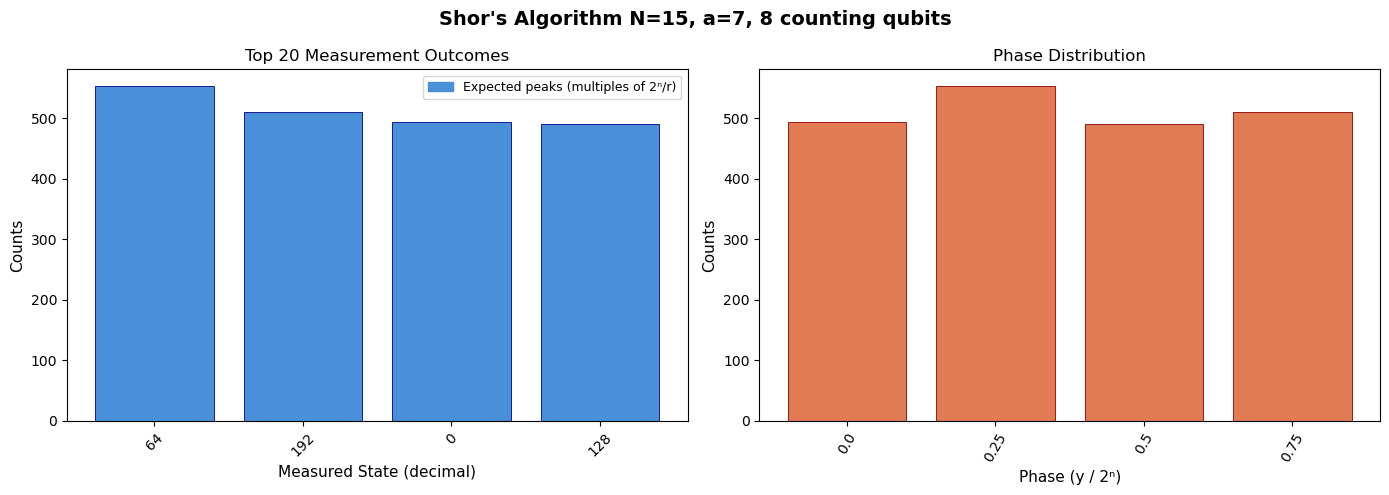

Figure saved as 'shors_n15_a7_histogram.png'


In [14]:
def plot_measurement_histogram(counts, N, a, n_count):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Shor's Algorithm N={N}, a={a}, {n_count} counting qubits",
                 fontsize=14, fontweight='bold')

    ax = axes[0]
    top_n = sorted(counts.items(), key=lambda x: -x[1])[:20]
    labels = [str(int(k, 2)) for k, v in top_n]
    values = [v for k, v in top_n]
    colors = ['#4A90D9' if int(k, 2) % (2 ** n_count // 4) == 0
              else '#B0C4DE' for k, v in top_n]
    bars = ax.bar(labels, values, color=colors, edgecolor='navy', linewidth=0.6)
    ax.set_xlabel('Measured State (decimal)', fontsize=11)
    ax.set_ylabel('Counts', fontsize=11)
    ax.set_title('Top 20 Measurement Outcomes', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    peak_patch = mpatches.Patch(color='#4A90D9', label='Expected peaks (multiples of 2ⁿ/r)')
    ax.legend(handles=[peak_patch], fontsize=9)

    ax2 = axes[1]
    Q = 2 ** n_count
    phases = [int(k, 2) / Q for k, v in counts.items()]
    phase_counts = Counter()
    for k, v in counts.items():
        ph = round(int(k, 2) / Q, 3)
        phase_counts[ph] += v
    ph_sorted = sorted(phase_counts.items())
    ax2.bar([str(p) for p, c in ph_sorted],
            [c for p, c in ph_sorted],
            color='#E07B54', edgecolor='darkred', linewidth=0.6)
    ax2.set_xlabel('Phase (y / 2ⁿ)', fontsize=11)
    ax2.set_ylabel('Counts', fontsize=11)
    ax2.set_title('Phase Distribution', fontsize=12)
    ax2.tick_params(axis='x', rotation=60)

    plt.tight_layout()
    plt.savefig(f'img/shors_n{N}_a{a}_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved as 'shors_n{N}_a{a}_histogram.png'")

plot_measurement_histogram(counts15, N=15, a=7, n_count=8)

## 2.7 Full Shor's Circuit for N = 21

For N = 21, we need **5 target qubits** (since $2^4 = 16 < 21 < 32 = 2^5$) and we use $a = 2$ (coprime to 21).

In [15]:
def shors_circuit_21(a=2, n_count=8):
    """
    Full Shor's algorithm circuit for N=21.
    """
    assert math.gcd(a, 21) == 1, f"a={a} must be coprime to 21"
    n_target = 5

    qc = QuantumCircuit(n_count + n_target, n_count)
    for q in range(n_count):
        qc.h(q)
    qc.x(n_count)

    qc.barrier()

    for j in range(n_count):
        power = 2 ** j
        gate = controlled_amod21(a, power)
        qc.append(gate, [j] + list(range(n_count, n_count + n_target)))

    qc.barrier()

    iqft = iqft_circuit(n_count)
    iqft.name = "Inverse QFT"
    qc.append(iqft, range(n_count))

    qc.barrier()

    qc.measure(range(n_count), range(n_count))

    return qc

qc21 = shors_circuit_21(a=2, n_count=8)
print(f"Circuit for N=21, a=2:")
print(f"  Total qubits : {qc21.num_qubits}")
print(f"  Total gates  : {qc21.size()}")
print(f"  Depth        : {qc21.depth()}")

counts21, factors21, time21 = run_shors(N=21, a=2, n_count=8, shots=2048)

Circuit for N=21, a=2:
  Total qubits : 13
  Total gates  : 26
  Depth        : 11

═══════════════════════════════════════════════════════
  Shor's Algorithm: N = 21, a = 2
═══════════════════════════════════════════════════════
  Simulation time  : 1.308 s (2048 shots)
  Distinct outcomes: 75

  Measurement        Decimal      Phase      r Factors
  -----------------------------------------------------------------
  00000000                 0     0.0000   None 
  10000000               128     0.5000   None 
  01010101                85     0.3320   None 
  11010101               213     0.8320      6 3 × 7
  10101011               171     0.6680   None 
  00101011                43     0.1680      6 3 × 7
  10101010               170     0.6641   None 
  01010110                86     0.3359   None 

  Factors of 21: {(3, 7)}


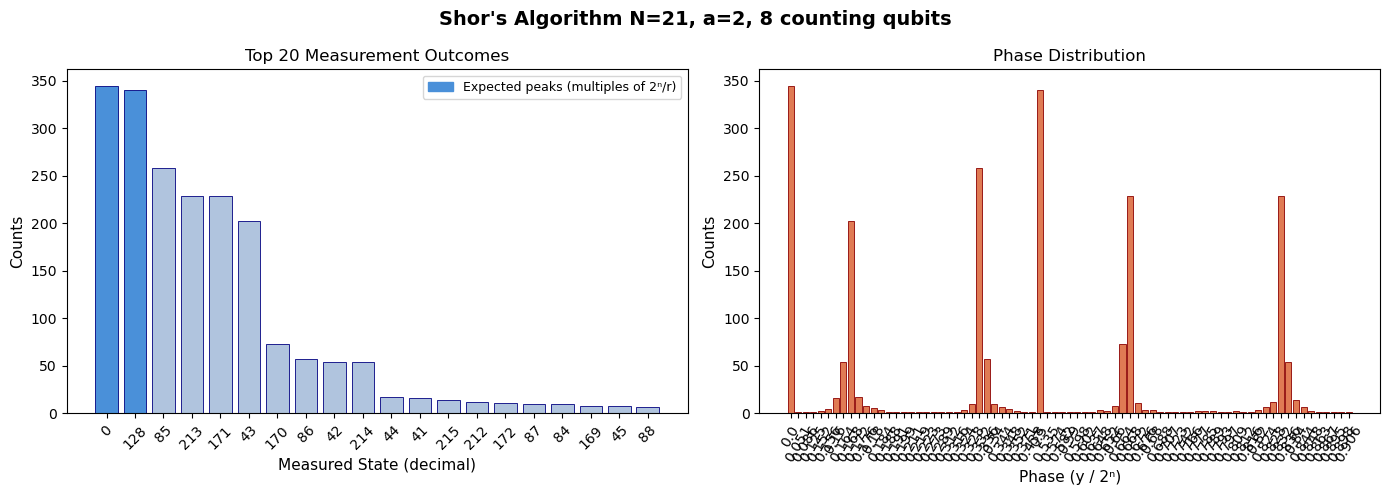

Figure saved as 'shors_n21_a2_histogram.png'


In [16]:
plot_measurement_histogram(counts21, N=21, a=2, n_count=8)

In [17]:
qc21_small = shors_circuit_21(a=2, n_count=4)
print("Compact circuit (4 counting qubits):")
print(qc15_small.draw(output='text', fold=120))
fig = qc21_small.draw(output='mpl')
fig.savefig("img/shor_circuit_N21.png", dpi=150, bbox_inches='tight')
plt.show()

Compact circuit (4 counting qubits):
     ┌───┐ ░                                                              ░ ┌──────────────┐ ░ ┌─┐         
q_0: ┤ H ├─░────────■─────────────────────────────────────────────────────░─┤0             ├─░─┤M├─────────
     ├───┤ ░        │                                                     ░ │              │ ░ └╥┘┌─┐      
q_1: ┤ H ├─░────────┼──────────────■──────────────────────────────────────░─┤1             ├─░──╫─┤M├──────
     ├───┤ ░        │              │                                      ░ │  Inverse QFT │ ░  ║ └╥┘┌─┐   
q_2: ┤ H ├─░────────┼──────────────┼──────────────■───────────────────────░─┤2             ├─░──╫──╫─┤M├───
     ├───┤ ░        │              │              │                       ░ │              │ ░  ║  ║ └╥┘┌─┐
q_3: ┤ H ├─░────────┼──────────────┼──────────────┼──────────────■────────░─┤3             ├─░──╫──╫──╫─┤M├
     ├───┤ ░ ┌──────┴──────┐┌──────┴──────┐┌──────┴──────┐┌──────┴──────┐ ░ └──────────────┘ ░  ║  

## 2.8 Exploring Multiple Values of a

Let's verify the algorithm works for multiple choices of base $a$.

In [18]:
def test_multiple_bases(N, coprime_bases, n_count=8, shots=1024):
    print(f"\nTesting Shor's for N={N} with bases: {coprime_bases}")
    print(f"{'a':>4} │ {'Order r':>8} │ {'Factors':>15} │ {'Success':>8}")
    print(f"{'─'*45}")

    results = {}
    for a in coprime_bases:
        if math.gcd(a, N) != 1:
            continue
        r, _ = classical_order_finding(a, N)
        success = False
        factor_str = "—"
        if r and r % 2 == 0:
            x = pow(a, r // 2, N)
            if x != N - 1:
                p = math.gcd(x + 1, N)
                q = math.gcd(x - 1, N)
                for f in [p, q]:
                    if 1 < f < N:
                        success = True
                        factor_str = f"{f} × {N//f}"
        print(f"{a:>4} │ {str(r):>8} │ {factor_str:>15} │ {'yes' if success else 'no':>8}")
        results[a] = {'r': r, 'success': success}

    return results

coprime_15 = [a for a in range(2, 15) if math.gcd(a, 15) == 1]
coprime_21 = [a for a in range(2, 21) if math.gcd(a, 21) == 1]

test_multiple_bases(15, coprime_15)
test_multiple_bases(21, coprime_21)


Testing Shor's for N=15 with bases: [2, 4, 7, 8, 11, 13, 14]
   a │  Order r │         Factors │  Success
─────────────────────────────────────────────
   2 │        4 │           3 × 5 │      yes
   4 │        2 │           3 × 5 │      yes
   7 │        4 │           3 × 5 │      yes
   8 │        4 │           3 × 5 │      yes
  11 │        2 │           5 × 3 │      yes
  13 │        4 │           3 × 5 │      yes
  14 │        2 │               — │       no

Testing Shor's for N=21 with bases: [2, 4, 5, 8, 10, 11, 13, 16, 17, 19, 20]
   a │  Order r │         Factors │  Success
─────────────────────────────────────────────
   2 │        6 │           7 × 3 │      yes
   4 │        3 │               — │       no
   5 │        6 │               — │       no
   8 │        2 │           7 × 3 │      yes
  10 │        6 │           3 × 7 │      yes
  11 │        6 │           7 × 3 │      yes
  13 │        2 │           3 × 7 │      yes
  16 │        3 │               — │       no
  1

{2: {'r': 6, 'success': True},
 4: {'r': 3, 'success': False},
 5: {'r': 6, 'success': False},
 8: {'r': 2, 'success': True},
 10: {'r': 6, 'success': True},
 11: {'r': 6, 'success': True},
 13: {'r': 2, 'success': True},
 16: {'r': 3, 'success': False},
 17: {'r': 6, 'success': False},
 19: {'r': 6, 'success': True},
 20: {'r': 2, 'success': False}}

---
# PART 3 — Comparison & Analysis

## 3.1 Complexity Comparison

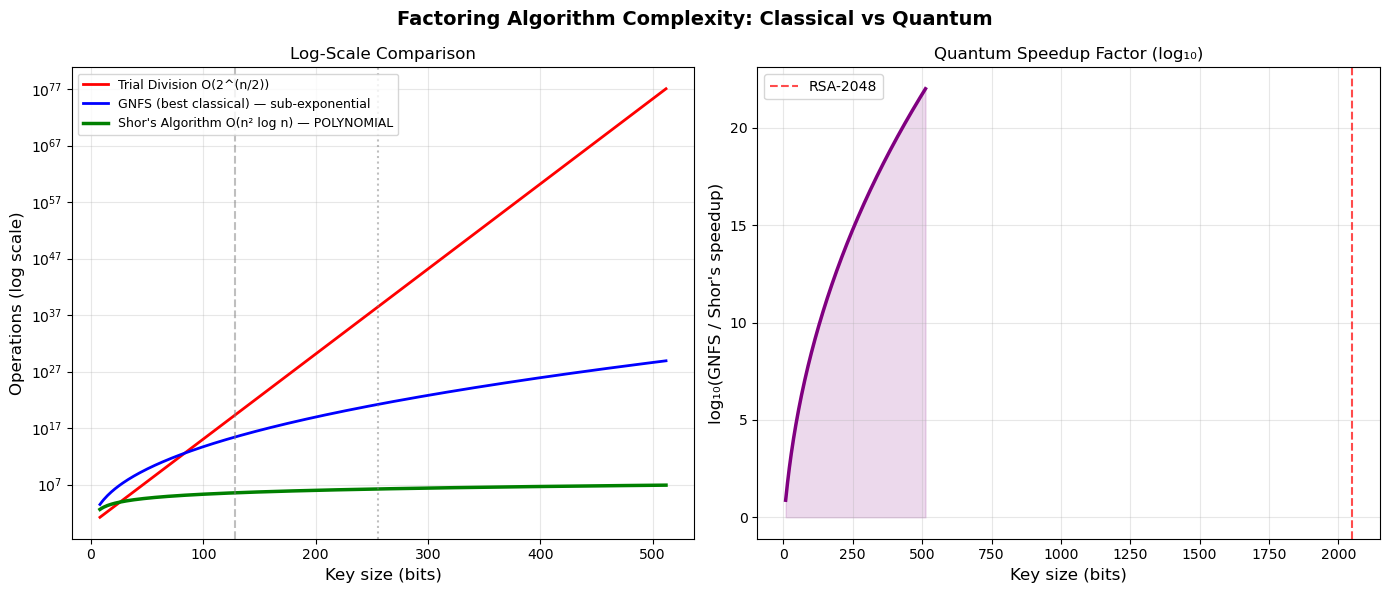

Figure saved as 'complexity_comparison.png'


In [19]:
def plot_complexity_comparison():
    n_bits = np.linspace(8, 512, 300)

    c = 1.923
    gnfs = np.exp(c * (n_bits ** (1/3)) * (np.log2(n_bits) ** (2/3)))

    shors = n_bits**2 * np.log2(n_bits) * np.log2(np.log2(n_bits + 1) + 1)

    trial = 2 ** (n_bits / 2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Factoring Algorithm Complexity: Classical vs Quantum",
                 fontsize=14, fontweight='bold')

    ax1.semilogy(n_bits, trial, 'r-', linewidth=2, label="Trial Division O(2^(n/2))")
    ax1.semilogy(n_bits, gnfs, 'b-', linewidth=2,
                 label="GNFS (best classical) — sub-exponential")
    ax1.semilogy(n_bits, shors, 'g-', linewidth=2.5, label="Shor's Algorithm O(n² log n) — POLYNOMIAL")
    ax1.set_xlabel("Key size (bits)", fontsize=12)
    ax1.set_ylabel("Operations (log scale)", fontsize=12)
    ax1.set_title("Log-Scale Comparison", fontsize=12)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.axvline(x=128, color='gray', linestyle='--', alpha=0.5, label="128-bit")
    ax1.axvline(x=256, color='gray', linestyle=':', alpha=0.5)

    ax2.plot(n_bits, np.log10(gnfs / shors), 'purple', linewidth=2.5)
    ax2.fill_between(n_bits, 0, np.log10(gnfs / shors), alpha=0.15, color='purple')
    ax2.set_xlabel("Key size (bits)", fontsize=12)
    ax2.set_ylabel("log₁₀(GNFS / Shor's speedup)", fontsize=12)
    ax2.set_title("Quantum Speedup Factor (log₁₀)", fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.axvline(x=2048, color='red', linestyle='--', alpha=0.7, label="RSA-2048")
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('img/complexity_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved as 'complexity_comparison.png'")

plot_complexity_comparison()

## 3.2 Step-by-Step Algorithm Comparison

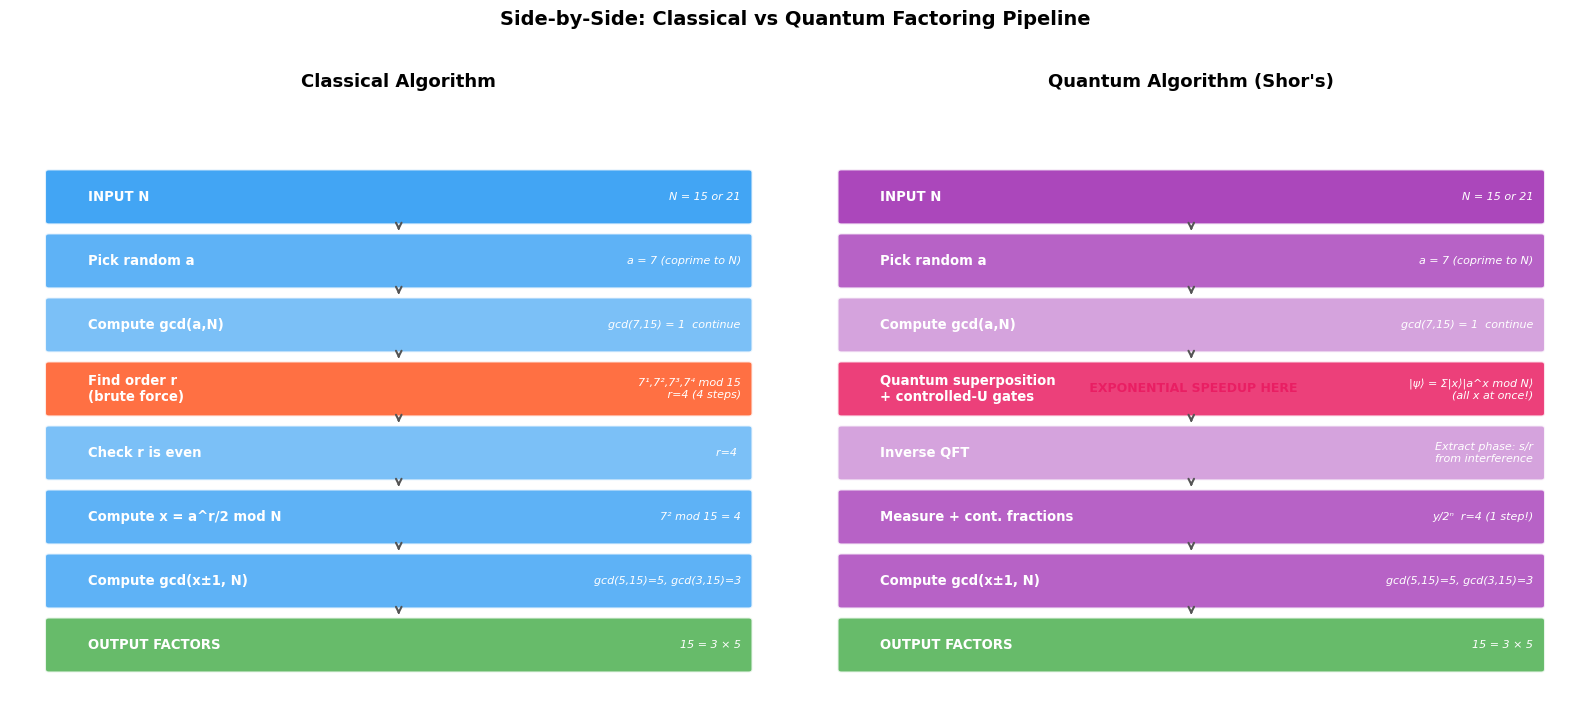

In [20]:
def visualize_algorithm_steps():
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("Side-by-Side: Classical vs Quantum Factoring Pipeline",
                 fontsize=14, fontweight='bold', y=1.02)

    classical_steps = [
        ("INPUT N", "N = 15 or 21"),
        ("Pick random a", "a = 7 (coprime to N)"),
        ("Compute gcd(a,N)", "gcd(7,15) = 1  continue"),
        ("Find order r\n(brute force)", "7¹,7²,7³,7⁴ mod 15\n r=4 (4 steps)"),
        ("Check r is even", "r=4 "),
        ("Compute x = a^r/2 mod N", "7² mod 15 = 4"),
        ("Compute gcd(x±1, N)", "gcd(5,15)=5, gcd(3,15)=3"),
        ("OUTPUT FACTORS", "15 = 3 × 5")
    ]

    quantum_steps = [
        ("INPUT N", "N = 15 or 21"),
        ("Pick random a", "a = 7 (coprime to N)"),
        ("Compute gcd(a,N)", "gcd(7,15) = 1  continue"),
        ("Quantum superposition\n+ controlled-U gates", "|ψ⟩ = Σ|x⟩|a^x mod N⟩\n(all x at once!)"),
        ("Inverse QFT", "Extract phase: s/r\nfrom interference"),
        ("Measure + cont. fractions", "y/2ⁿ  r=4 (1 step!)"),
        ("Compute gcd(x±1, N)", "gcd(5,15)=5, gcd(3,15)=3"),
        ("OUTPUT FACTORS", "15 = 3 × 5")
    ]

    colors_c = ['#2196F3', '#42A5F5', '#64B5F6', '#FF5722', '#64B5F6', '#42A5F5', '#42A5F5', '#4CAF50']
    colors_q = ['#9C27B0', '#AB47BC', '#CE93D8', '#E91E63', '#CE93D8', '#AB47BC', '#AB47BC', '#4CAF50']

    for ax, steps, colors, title in [
        (axes[0], classical_steps, colors_c, "Classical Algorithm"),
        (axes[1], quantum_steps, colors_q, "Quantum Algorithm (Shor's)")
    ]:
        ax.set_xlim(0, 10)
        ax.set_ylim(-1, len(steps) + 0.5)
        ax.axis('off')
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

        for i, (step_name, detail) in enumerate(reversed(steps)):
            y = i
            color = colors[len(steps) - 1 - i]
            rect = mpatches.FancyBboxPatch(
                (0.5, y - 0.38), 9, 0.76,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor='white', linewidth=1.5,
                alpha=0.85
            )
            ax.add_patch(rect)
            ax.text(1.0, y, step_name, va='center', ha='left',
                    fontsize=9.5, fontweight='bold', color='white')
            ax.text(9.4, y, detail, va='center', ha='right',
                    fontsize=8, color='white', style='italic')

            if i < len(steps) - 1:
                ax.annotate('', xy=(5, y + 0.38 + 0.05),
                            xytext=(5, y + 0.38 + 0.2),
                            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

    axes[1].text(5, 3.0 + 0.95, ' EXPONENTIAL SPEEDUP HERE',
                ha='center', fontsize=9, color='#E91E63', fontweight='bold')

    plt.tight_layout()
    plt.savefig('img/algorithm_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_algorithm_steps()

## 3.3 Noise Analysis:Effect of Simulated Quantum Errors

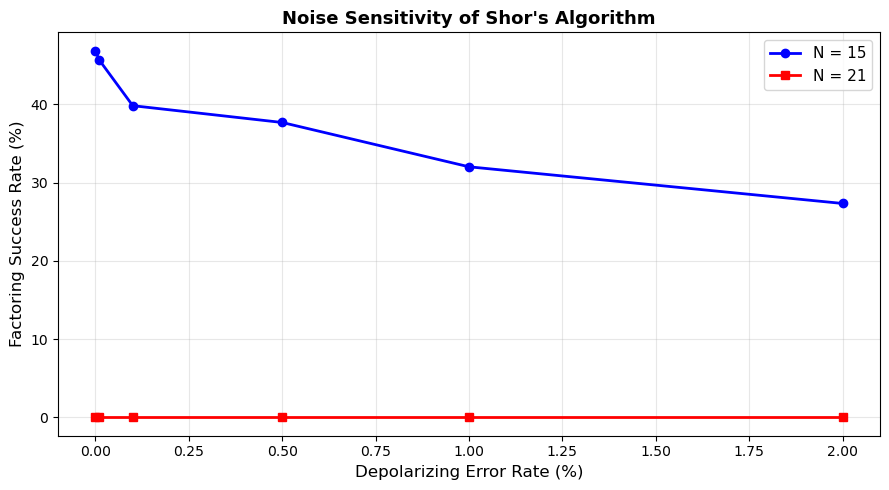

Noise analysis saved as 'noise_analysis.png'


In [21]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

def run_with_noise(N, a, n_count=4, shots=512, error_rate=0.001):
    """
    Run Shor's circuit with depolarizing noise and return the factoring success rate.
    Uses n_count=4 (sufficient for period detection and much faster to simulate).
    The circuit and base simulator are built once; only the noise model changes per call.
    """
    if N == 15:
        qc = shors_circuit_15(a=a, n_count=n_count)
    else:
        qc = shors_circuit_21(a=a, n_count=n_count)

    noise_model = NoiseModel()
    error1 = depolarizing_error(error_rate, 1)
    error2 = depolarizing_error(error_rate * 10, 2)
    noise_model.add_all_qubit_quantum_error(error1, ['h', 'x', 's', 't'])
    noise_model.add_all_qubit_quantum_error(error2, ['cx', 'cp', 'swap'])

    sim = AerSimulator(noise_model=noise_model)
    t_qc = transpile(qc, sim)
    counts = sim.run(t_qc, shots=shots).result().get_counts()

    correct = 0
    for bitstring, count in counts.items():
        measured_int = int(bitstring, 2)
        r = get_period_from_measurement(measured_int, n_count, N, a)
        if r and r % 2 == 0:
            x = pow(a, r // 2, N)
            if x != N - 1:
                for f in [math.gcd(x + 1, N), math.gcd(x - 1, N)]:
                    if 1 < f < N:
                        correct += count
                        break
    return correct / shots


error_rates = [0.0, 0.0001, 0.001, 0.005, 0.01, 0.02]
success_15 = [run_with_noise(15, 7, n_count=4, shots=512, error_rate=e) for e in error_rates]
success_21 = [run_with_noise(21, 2, n_count=4, shots=512, error_rate=e) for e in error_rates]

plt.figure(figsize=(9, 5))
plt.plot([e * 100 for e in error_rates], [s * 100 for s in success_15],
         'b-o', linewidth=2, label='N = 15')
plt.plot([e * 100 for e in error_rates], [s * 100 for s in success_21],
         'r-s', linewidth=2, label='N = 21')
plt.xlabel('Depolarizing Error Rate (%)', fontsize=12)
plt.ylabel('Factoring Success Rate (%)', fontsize=12)
plt.title("Noise Sensitivity of Shor's Algorithm", fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('img/noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Noise analysis saved as 'noise_analysis.png'")




## References

[1] P. W. Shor, “Polynomial-time algorithms for prime factorization and discrete logarithms on a quantum computer,” *SIAM Journal on Computing*, vol. 26, no. 5, pp. 1484–1509, 1997. Preprint: arXiv:quant-ph/9508027.

[2] U. Skosana and M. Tame, “Demonstration of Shor’s factoring algorithm for N = 21 on IBM quantum processors,” *Scientific Reports*, vol. 11, article 16599, Aug. 2021. DOI: 10.1038/s41598-021-95973-w.

[3] S. S. Kavitha, N. Kaulgud, B. S. Sharmila, B. M. Nandini, R. R. Ram, and D. Petkar, “Quantum Shor’s algorithm vs. classical General Number Field Sieve (GNFS) approach for large integer factorization,” in *Proceedings of the 2025 International Conference on Next Generation Communication and Information Processing (INCIP-2025)*, IEEE, 2025, pp. 357–362. DOI: 10.1109/INCIP64058.2025.11019635.

[4] O. Bonnet, “Simulation of hybrid classical–quantum strategies for accelerating RSA factorization in Qiskit,” unpublished manuscript, Dec. 2025.

[5] P. Bagourd, J. Jang-Jaccard, V. Lenders, A. Mermoud, T. Hoefler, and C. Hempel, “Practical challenges in executing Shor’s algorithm on existing quantum platforms,” arXiv:2512.15330v2 [quant-ph], Dec. 2025.